## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course 

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [25]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`. 

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable 

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
``` 
You can use: 
```
np.add(b,c,out = a) # puts result in `a`
```

In [26]:
# (re-)load layers
%run modules.ipynb

In [27]:
ReLU.updateGradInput??

Signature: ReLU.updateGradInput(self, input, gradOutput)
Docstring:
Computing the gradient of the module with respect to its own input. 
This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

The shape of `gradInput` is always the same as the shape of `input`.

Make sure to both store the gradients in `gradInput` field and return it.
Source:   
    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput, input > 0)
        return self.gradInput
File:      /tmp/ipykernel_119487/3738734854.py
Type:      function

# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

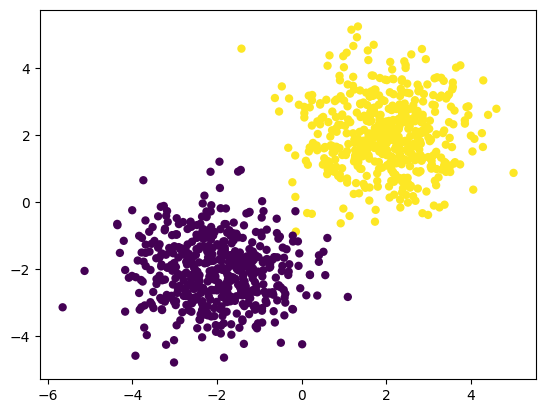

In [28]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging. 

In [29]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then 

# net = Sequential()
# net.add(Linear(2, 4))
# net.add(ReLU())
# net.add(Linear(4, 2))
# net.add(LogSoftMax())

Linear 2 -> 2
LogSoftMax



Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [30]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 10
batch_size = 128

In [31]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]
        
    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        
        batch_idx = indices[start:end]
    
        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

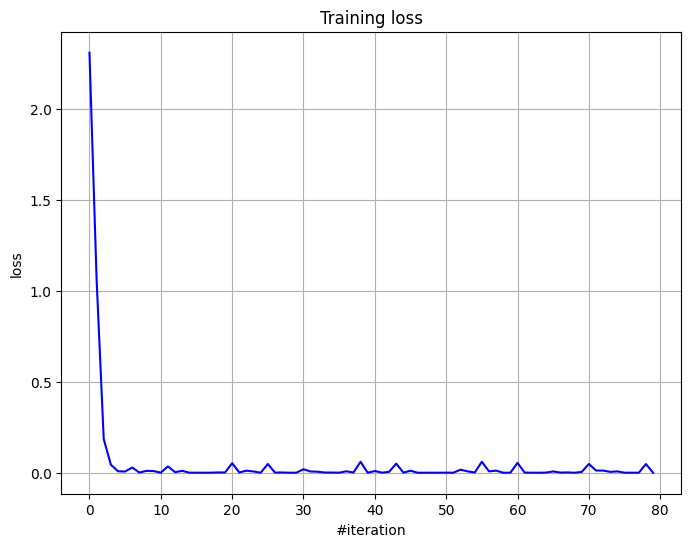

Current loss: 0.000002


In [32]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):
        
        net.zeroGradParameters()
        
        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)
    
        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)
        
        # Update weights
        sgd_momentum(net.getParameters(), 
                     net.getGradParameters(), 
                     optimizer_config,
                     optimizer_state)      
        
        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))
        
    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.grid(True)
    plt.show()
    
    print('Current loss: %f' % loss)    

# Digit classification 

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [33]:
# !wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

In [34]:
# не сработало - HTTP Error 404: Not Found, wget http://deeplearning.net/data/mnist/mnist.pkl.gz тоже не качает
# скачал отсюда https://github.com/fgnt/mnist/tree/master
import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

One-hot encode the labels first.

In [35]:
X_train = np.reshape(X_train, (-1, 28*28))
X_val = np.reshape(X_val, (-1, 28*28))
X_test = np.reshape(X_test, (-1, 28*28))

In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
y_train

array([5, 0, 4, ..., 8, 4, 8], dtype=uint8)

In [38]:
encoder = OneHotEncoder()
encoder.fit(y_train.reshape(-1,1))

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [39]:
encoder.categories_

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)]

In [40]:
y_train = encoder.transform(y_train.reshape(-1,1))
y_test  = encoder.transform(y_test.reshape(-1,1))
y_val   = encoder.transform(y_val.reshape(-1,1))

In [41]:
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx].toarray()

In [42]:
def accuracy(y_true, y_pred) -> float:
    batch_size = len(y_true)
    true_ind = np.argmax(y_true, axis=1)
    pred_ind = np.argmax(y_pred, axis=1)
    acc = np.equal(true_ind, pred_ind).sum()
    acc /= batch_size
    return acc

In [43]:
def eval_model(model, X_val: np.array, y_val: np.array, batch_size: int = 32) -> float:
    model.training = False
    acc = 0.0
    n_batches = 0
    for x_batch, y_batch in get_batches((X_val, y_val), batch_size):
        predictions = model.forward(x_batch)
        acc += accuracy(y_batch, predictions)
        n_batches += 1
    return acc / n_batches

In [44]:
def train_net(
    model,
    X_train: np.array,
    y_train: np.array,
    X_valid: np.array,
    y_valid: np.array,
    train_alg,
    criterion,
    optimizer_config: dict,
    n_epoch: int,
    batch_size: int = 32,
):
    loss_history = []
    optimizer_state = {}
    model.training = True
    for i in range(1, n_epoch + 1):
        print(f"Epoch: {i}/{n_epoch}")
        train_acc = 0.0
        n_train_batches = 0
        for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
            model.zeroGradParameters()

            # Forward
            predictions = model.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)

            # Backward
            dp = criterion.backward(predictions, y_batch)
            model.backward(x_batch, dp)

            # Update weights
            train_alg(
                model.getParameters(),
                model.getGradParameters(),
                optimizer_config,
                optimizer_state,
            )

            loss_history.append(loss)
            n_train_batches += 1
            train_acc += accuracy(y_batch, predictions)

        print("Current loss: %f" % loss)
        val_acc = eval_model(model, X_valid, y_valid)

        train_acc /= n_train_batches
        print(f"Train acc: {train_acc:.3f}")
        print(f"Val acc: {val_acc:.3f}")
        model.training = True
        
    return model, loss_history

In [45]:
# Для дальнейших экспериментов напишем функции, возвращающие 2 модели: 
# 1 - последовательность линейных функций + функция активации
# 2 - то же самое, только добавлены слои BatchNormalization + ChannelwiseScaling

In [46]:
def get_model_1(act_func):
    net = Sequential()
    net.add(Linear(28 * 28, 256))
    net.add(Linear(256, 256))
    net.add(act_func())
    net.add(Linear(256, 128))
    net.add(act_func())
    net.add(Linear(128, 64))
    net.add(act_func())
    net.add(Linear(64, 10))
    net.add(SoftMax())
    return net

In [47]:
def get_model_2(act_func):
    net = Sequential()
    net.add(BatchNormalization())
    net.add(ChannelwiseScaling(28 * 28))
    net.add(Linear(28 * 28, 256))
    net.add(act_func())
    net.add(Linear(256, 256))
    net.add(act_func())
    net.add(Linear(256, 128))
    net.add(act_func())
    net.add(Linear(128, 64))
    net.add(act_func())
    net.add(Linear(64, 10))
    net.add(SoftMax())
    return net

Compare ReLU, ELU, LeakyReLU, SoftPlus activation functions

In [48]:
def module_name(mod):
    name = repr(mod)
    return name.split('.')[-1].split('\'')[0]

In [49]:
# Сравниваем различные функции активации на модели 1

In [50]:
results_1 = []
optimizer_config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2':0.999, 'epsilon':1e-8}
criterion = ClassNLLCriterionUnstable()

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_1(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        adam_optimizer, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_1.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.461424
Train acc: 0.882
Val acc: 0.940
Epoch: 2/2
Current loss: 0.056072
Train acc: 0.945
Val acc: 0.962
ELU
Epoch: 1/2
Current loss: 0.734556
Train acc: 0.896
Val acc: 0.947
Epoch: 2/2
Current loss: 0.078792
Train acc: 0.946
Val acc: 0.959
LeakyReLU
Epoch: 1/2
Current loss: 0.117760
Train acc: 0.884
Val acc: 0.935
Epoch: 2/2
Current loss: 0.548877
Train acc: 0.948
Val acc: 0.957
SoftPlus
Epoch: 1/2
Current loss: 0.154644
Train acc: 0.872
Val acc: 0.944
Epoch: 2/2
Current loss: 0.197679
Train acc: 0.943
Val acc: 0.951


Text(0.5, 0.98, 'Model 1')

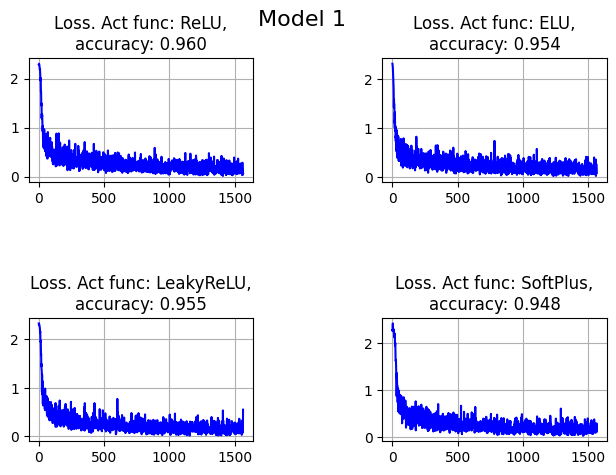

In [54]:
fig, axs = plt.subplots(2, 2, )

positions = [(0,0), (0,1), (1,0), (1,1)]
for pos, res in zip(positions, results_1):
    axs[pos].plot(res['loss'], "b")
    title = f'Loss. Act func: {res['act_func']},\naccuracy: {res['accuracy']:.3f}'
    axs[pos].set_title(title)
    axs[pos].grid(True)

plt.tight_layout(h_pad=5, w_pad=7)
plt.suptitle('Model 1', fontsize=16)

**Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions

In [55]:
# Сравниваем различные функции активации на модели 2

In [53]:
results_2 = []
for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_2(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        adam_optimizer, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_2.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.112490
Train acc: 0.816
Val acc: 0.945
Epoch: 2/2
Current loss: 0.006742
Train acc: 0.956
Val acc: 0.956
ELU
Epoch: 1/2
Current loss: 0.691492
Train acc: 0.833
Val acc: 0.918
Epoch: 2/2
Current loss: 0.204551
Train acc: 0.923
Val acc: 0.929
LeakyReLU
Epoch: 1/2
Current loss: 0.223878
Train acc: 0.844
Val acc: 0.946
Epoch: 2/2
Current loss: 0.136002
Train acc: 0.957
Val acc: 0.963
SoftPlus
Epoch: 1/2
Current loss: 0.414021
Train acc: 0.773
Val acc: 0.918
Epoch: 2/2
Current loss: 0.323930
Train acc: 0.928
Val acc: 0.941


Text(0.5, 0.98, 'Model 2')

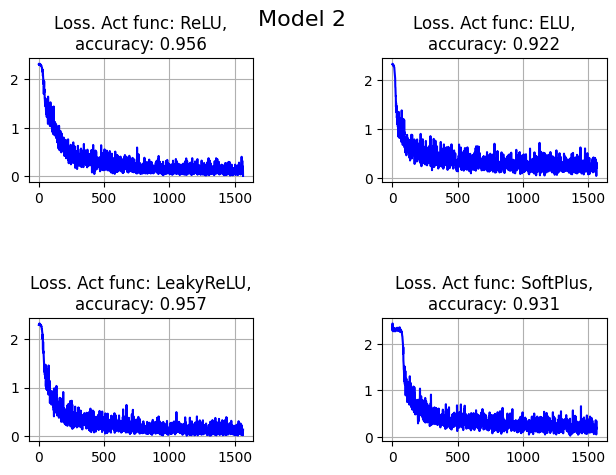

In [56]:
fig, axs = plt.subplots(2, 2, )

positions = [(0,0), (0,1), (1,0), (1,1)]
for pos, res in zip(positions, results_2):
    axs[pos].plot(res['loss'], "b")
    title = f'Loss. Act func: {res['act_func']},\naccuracy: {res['accuracy']:.3f}'
    axs[pos].set_title(title)
    axs[pos].grid(True)

plt.tight_layout(h_pad=5, w_pad=7)
plt.suptitle('Model 2', fontsize=16)

Text(0.5, 0.98, 'Models compare')

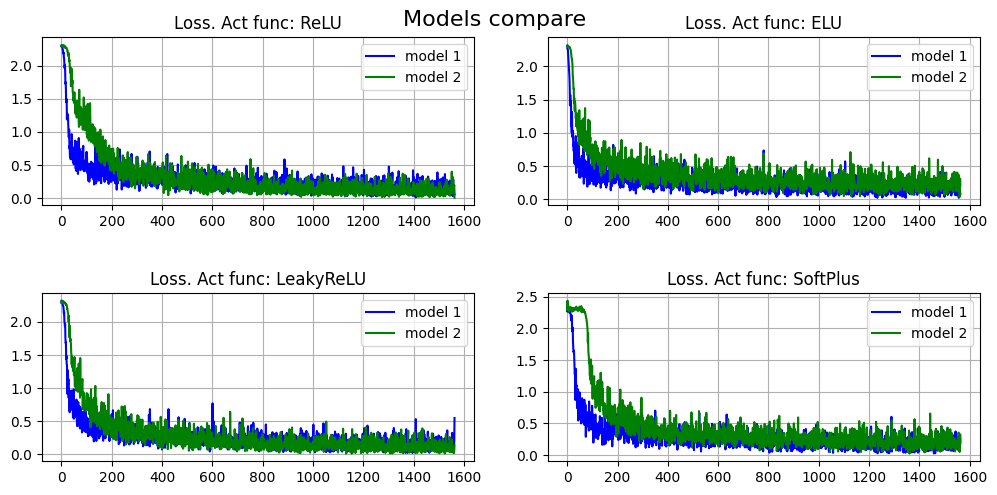

In [59]:
fig, axs = plt.subplots(2, 2, figsize=(10,5))

positions = [(0,0), (0,1), (1,0), (1,1)]
for i in range(4):
    pos = positions[i]
    res_1 = results_1[i]
    res_2 = results_2[i]
    # axs[pos].set_xscale('log')
    axs[pos].plot(res_1['loss'], "b", label='model 1')
    axs[pos].plot(res_2['loss'], "g", label='model 2')
    title = f'Loss. Act func: {res_1['act_func']}'
    axs[pos].legend()
    axs[pos].set_title(title)
    axs[pos].grid(True)

plt.tight_layout(h_pad=3, w_pad=3)
plt.suptitle('Models loss compare', fontsize=16)

In [60]:
results_sgd_1 = []
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_1(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        sgd_momentum, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_sgd_1.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.012884
Train acc: 0.839
Val acc: 0.906
Epoch: 2/2
Current loss: 0.060793
Train acc: 0.924
Val acc: 0.941
ELU
Epoch: 1/2
Current loss: 0.015779
Train acc: 0.836
Val acc: 0.899
Epoch: 2/2
Current loss: 2.175983
Train acc: 0.674
Val acc: 0.107
LeakyReLU
Epoch: 1/2
Current loss: 0.279145
Train acc: 0.839
Val acc: 0.921
Epoch: 2/2
Current loss: 0.264236
Train acc: 0.918
Val acc: 0.946
SoftPlus
Epoch: 1/2
Current loss: 0.037717
Train acc: 0.631
Val acc: 0.892
Epoch: 2/2
Current loss: 0.353563
Train acc: 0.924
Val acc: 0.940


In [61]:
results_adam_1 = []
optimizer_config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2':0.999, 'epsilon':1e-8}
optimizer_state = {}

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_1(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        adam_optimizer, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_adam_1.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.069655
Train acc: 0.884
Val acc: 0.944
Epoch: 2/2
Current loss: 0.044110
Train acc: 0.948
Val acc: 0.960
ELU
Epoch: 1/2
Current loss: 0.364462
Train acc: 0.891
Val acc: 0.932
Epoch: 2/2
Current loss: 0.061763
Train acc: 0.946
Val acc: 0.958
LeakyReLU
Epoch: 1/2
Current loss: 0.099071
Train acc: 0.889
Val acc: 0.945
Epoch: 2/2
Current loss: 0.020255
Train acc: 0.948
Val acc: 0.958
SoftPlus
Epoch: 1/2
Current loss: 0.097005
Train acc: 0.868
Val acc: 0.938
Epoch: 2/2
Current loss: 0.005481
Train acc: 0.943
Val acc: 0.947


Text(0.5, 0.98, 'Model 1')

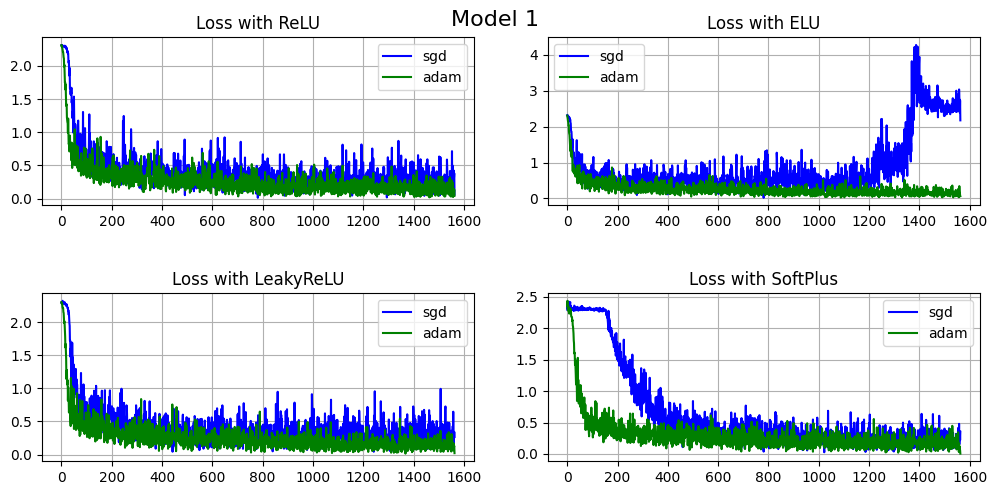

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(10,5))

positions = [(0,0), (0,1), (1,0), (1,1)]

l1, = axs[0,0].plot(results_sgd_1[0]['loss'], 'b', label='sgd')
l2, = axs[0,0].plot(results_adam_1[0]['loss'], 'g', label='adam')
axs[0,0].set_title('Loss with ReLU')
axs[0,0].legend()
axs[0,0].grid(True)

# случилось переобучение
l3, = axs[0,1].plot(results_sgd_1[1]['loss'], 'b', label='sgd')
l4, = axs[0,1].plot(results_adam_1[1]['loss'], 'g', label='adam')
axs[0,1].set_title('Loss with ELU')
axs[0,1].legend()
axs[0,1].grid(True)

l5, = axs[1,0].plot(results_sgd_1[2]['loss'], 'b', label='sgd')
l6, = axs[1,0].plot(results_adam_1[2]['loss'], 'g', label='adam')
axs[1,0].set_title('Loss with LeakyReLU')
axs[1,0].legend()
axs[1,0].grid(True)

l7, = axs[1,1].plot(results_sgd_1[3]['loss'], 'b', label='sgd')
l8, = axs[1,1].plot(results_adam_1[3]['loss'], 'g', label='adam')
axs[1,1].set_title('Loss with SoftPlus')
axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout(h_pad=3, w_pad=3)
plt.suptitle('Model 1', fontsize=16)

In [63]:
results_sgd_2 = []
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_2(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        sgd_momentum, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_sgd_2.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.285027
Train acc: 0.579
Val acc: 0.940
Epoch: 2/2
Current loss: 1.443273
Train acc: 0.947
Val acc: 0.959
ELU
Epoch: 1/2
Current loss: 0.146720
Train acc: 0.760
Val acc: 0.908
Epoch: 2/2
Current loss: 0.051495
Train acc: 0.923
Val acc: 0.943
LeakyReLU
Epoch: 1/2
Current loss: 0.423430
Train acc: 0.557
Val acc: 0.931
Epoch: 2/2
Current loss: 0.207287
Train acc: 0.946
Val acc: 0.957
SoftPlus
Epoch: 1/2
Current loss: 2.352020
Train acc: 0.107
Val acc: 0.107
Epoch: 2/2
Current loss: 2.298590
Train acc: 0.108
Val acc: 0.106


In [64]:
results_adam_2 = []
optimizer_config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2':0.999, 'epsilon':1e-8}
optimizer_state = {}

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_2(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        adam_optimizer, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=64,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_adam_2.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.425831
Train acc: 0.838
Val acc: 0.935
Epoch: 2/2
Current loss: 0.173287
Train acc: 0.959
Val acc: 0.962
ELU
Epoch: 1/2
Current loss: 0.324959
Train acc: 0.843
Val acc: 0.910
Epoch: 2/2
Current loss: 0.084136
Train acc: 0.923
Val acc: 0.930
LeakyReLU
Epoch: 1/2
Current loss: 0.096786
Train acc: 0.848
Val acc: 0.948
Epoch: 2/2
Current loss: 0.201266
Train acc: 0.958
Val acc: 0.955
SoftPlus
Epoch: 1/2
Current loss: 0.067002
Train acc: 0.773
Val acc: 0.905
Epoch: 2/2
Current loss: 0.923074
Train acc: 0.928
Val acc: 0.945


Text(0.5, 0.98, 'Model 2')

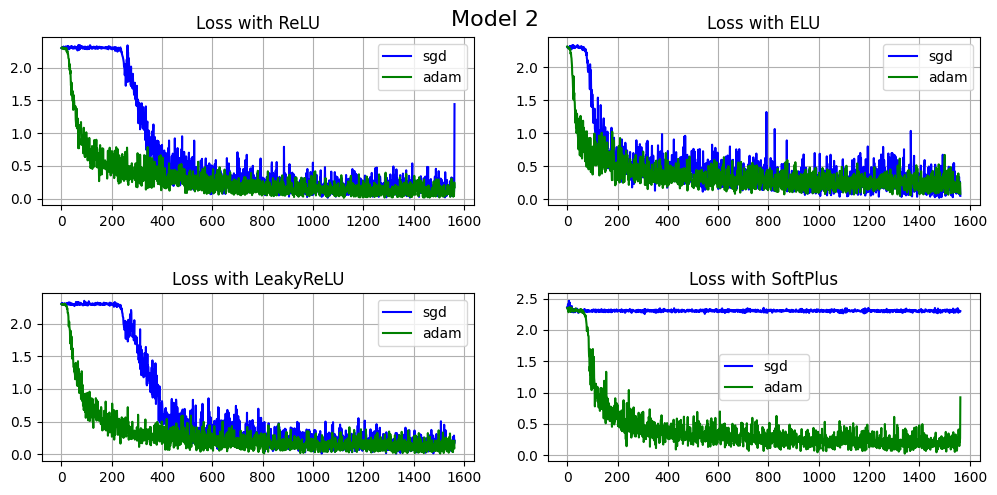

In [65]:
fig, axs = plt.subplots(2, 2, figsize=(10,5))

positions = [(0,0), (0,1), (1,0), (1,1)]

l1, = axs[0,0].plot(results_sgd_2[0]['loss'], 'b', label='sgd')
l2, = axs[0,0].plot(results_adam_2[0]['loss'], 'g', label='adam')
axs[0,0].set_title('Loss with ReLU')
axs[0,0].legend()
axs[0,0].grid(True)

l3, = axs[0,1].plot(results_sgd_2[1]['loss'], 'b', label='sgd')
l4, = axs[0,1].plot(results_adam_2[1]['loss'], 'g', label='adam')
axs[0,1].set_title('Loss with ELU')
axs[0,1].legend()
axs[0,1].grid(True)

l5, = axs[1,0].plot(results_sgd_2[2]['loss'], 'b', label='sgd')
l6, = axs[1,0].plot(results_adam_2[2]['loss'], 'g', label='adam')
axs[1,0].set_title('Loss with LeakyReLU')
axs[1,0].legend()
axs[1,0].grid(True)

l7, = axs[1,1].plot(results_sgd_2[3]['loss'], 'b', label='sgd')
l8, = axs[1,1].plot(results_adam_2[3]['loss'], 'g', label='adam')
axs[1,1].set_title('Loss with SoftPlus')
axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout(h_pad=3, w_pad=3)
plt.suptitle('Model 2', fontsize=16)

In [70]:
import pandas as pd

In [77]:
data = {"model": [], "opt_alg": [], "activation": [], "accuracy": []}
for i, model_results in enumerate([(results_sgd_1, results_adam_1), (results_sgd_2, results_adam_2)], 1):
    net_model = f"Model_{i}"
    for res, alg in zip(model_results, ['sgd', 'adam']):
        for item in res:
            data["model"].append(net_model)
            data["opt_alg"].append(alg)
            data["activation"].append(item["act_func"])
            data["accuracy"].append(item["accuracy"])

In [78]:
df = pd.DataFrame(data)

In [80]:
df.sort_values(by="accuracy", ascending=False)

,model,opt_alg,activation,accuracy
12,Model_2,adam,ReLU,0.963558
4,Model_1,adam,ReLU,0.958367
14,Model_2,adam,LeakyReLU,0.956470
10,Model_2,sgd,LeakyReLU,0.956270
5,Model_1,adam,ELU,0.955571
6,Model_1,adam,LeakyReLU,0.955471
8,Model_2,sgd,ReLU,0.950379
7,Model_1,adam,SoftPlus,0.948183
15,Model_2,adam,SoftPlus,0.940795
9,Model_2,sgd,ELU,0.940296


- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions. 
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5. 

Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

**Некоторые выводы**:
1. У нас очень простые данные, на которых все работает хорошо - даже таки простые модели, как в данном эксперименте;
2. В данном примере лучше всего сработала простая ReLU без модицикаций - как для первой, так и для второй модели;
3. В двух экспериментах столкнулись с переобучением, дополнительная регуляризация не помешает;
4. Судя по графикам, adam более устойчивый алгоитм в том смысле, что колебания loss функции меньше, а график сильнее "прижат ко дну".

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [81]:
def get_model_3(act_func):
    net = Sequential()
    net.add(BatchNormalization())
    net.add(ChannelwiseScaling(28 * 28))
    net.add(Linear(28 * 28, 256))
    net.add(act_func())
    net.add(Linear(256, 256))
    net.add(act_func())
    net.add(Linear(256, 128))
    net.add(act_func())
    net.add(Linear(128, 64))
    net.add(act_func())
    net.add(Dropout(0.5))
    net.add(Linear(64, 10))
    net.add(SoftMax())
    return net

In [82]:
results_model_3 = []
optimizer_config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2':0.999, 'epsilon':1e-8}
optimizer_state = {}

for act_func in [ReLU, ELU, LeakyReLU, SoftPlus]:
    print(module_name(act_func))
    model = get_model_3(act_func)
    
    model, loss = train_net(
        model, 
        X_train, y_train, 
        X_val, y_val, 
        adam_optimizer, 
        criterion, 
        optimizer_config.copy(), 
        n_epoch=2, 
        batch_size=128,
    )
    
    acc = eval_model(model, X_test, y_test)
    model_res = {
        'model': model,
        'act_func': module_name(act_func),
        'accuracy': acc,
        'loss': loss
    }
    results_model_3.append(model_res)

ReLU
Epoch: 1/2
Current loss: 0.185386
Train acc: 0.726
Val acc: 0.911
Epoch: 2/2
Current loss: 0.137325
Train acc: 0.935
Val acc: 0.945
ELU
Epoch: 1/2
Current loss: 0.283507
Train acc: 0.793
Val acc: 0.896
Epoch: 2/2
Current loss: 0.371629
Train acc: 0.910
Val acc: 0.917
LeakyReLU
Epoch: 1/2
Current loss: 0.321877
Train acc: 0.758
Val acc: 0.927
Epoch: 2/2
Current loss: 0.191623
Train acc: 0.942
Val acc: 0.946
SoftPlus
Epoch: 1/2
Current loss: 0.594680
Train acc: 0.555
Val acc: 0.861
Epoch: 2/2
Current loss: 0.302067
Train acc: 0.897
Val acc: 0.910


Text(0.5, 0.98, 'Model 3')

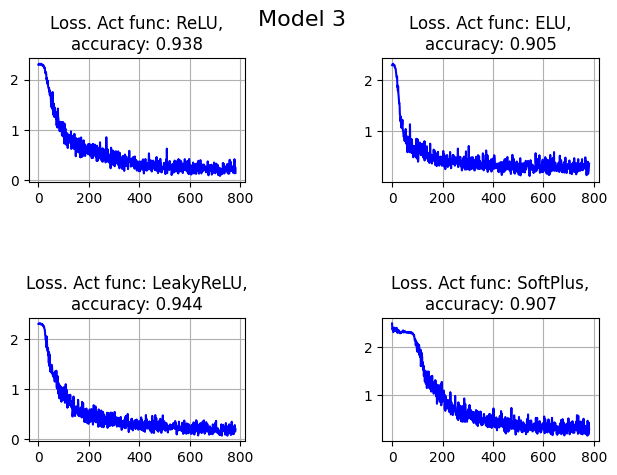

In [83]:
fig, axs = plt.subplots(2, 2, )

positions = [(0,0), (0,1), (1,0), (1,1)]
for pos, res in zip(positions, results_model_3):
    axs[pos].plot(res['loss'], "b")
    title = f'Loss. Act func: {res['act_func']},\naccuracy: {res['accuracy']:.3f}'
    axs[pos].set_title(title)
    axs[pos].grid(True)

plt.tight_layout(h_pad=5, w_pad=7)
plt.suptitle('Model 3', fontsize=16)

In [87]:
data_3 = {"model": [], "opt_alg": [], "activation": [], "accuracy": []}
for item in results_model_3:
    data_3["model"].append("Model_3")
    data_3["opt_alg"].append("adam")
    data_3["activation"].append(item["act_func"])
    data_3["accuracy"].append(item["accuracy"])

In [89]:
df_3 = pd.DataFrame(data_3)

In [91]:
df = pd.concat([df, df_3])

In [94]:
df.sort_values(by="accuracy", ascending=False)

,model,opt_alg,activation,accuracy
12,Model_2,adam,ReLU,0.963558
4,Model_1,adam,ReLU,0.958367
14,Model_2,adam,LeakyReLU,0.956470
10,Model_2,sgd,LeakyReLU,0.956270
5,Model_1,adam,ELU,0.955571
6,Model_1,adam,LeakyReLU,0.955471
8,Model_2,sgd,ReLU,0.950379
7,Model_1,adam,SoftPlus,0.948183
2,Model_3,adam,LeakyReLU,0.943990
15,Model_2,adam,SoftPlus,0.940795


Print here your accuracy on test set. It should be around 90%.

In [95]:
# Добавление dropout не сильно повлияло на результаты, модель с dropout не попала в топ-3. Но и не переобучилась

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [208]:
# !pip install torchvision

In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader
import tqdm

In [126]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 14 * 14, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=6272, out_features=128, bias=True)
  (7): ReLU()
  (8): Linear(in_features=128, out_features=10, bias=True)
)

In [199]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [200]:
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

In [201]:
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y_val = y_val.reshape(-1,1)

In [202]:
train_loader = DataLoader((X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader((X_test, y_test), batch_size=32, shuffle=False)

In [207]:
for epoch in range(3):
    model = model.train()
    train_loss = []
    
    for x_batch, y_batch in get_batches((X_train, y_train), batch_size=32):
        y_batch = y_batch.squeeze(axis=1)
        x_batch = torch.from_numpy(x_batch).to(device)
        y_batch = torch.from_numpy(y_batch).to(device)
        
        x_batch = x_batch.unsqueeze(1)
        
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        train_loss.append(loss.detach())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    train_loss = torch.stack(train_loss).mean()
    print(
        f"Epoch {epoch},",
        f"train_loss: {train_loss.item():.8f}",
    )

    model = model.eval()
    valid_accs = []
    for x_batch, y_batch in get_batches((X_val, y_val), batch_size=32):
        y_batch = y_batch.squeeze(axis=1)
        x_batch = torch.from_numpy(x_batch).to(device)
        y_batch = torch.from_numpy(y_batch).to(device)
        x_batch = x_batch.unsqueeze(1)
        
        with torch.no_grad():
            pred = model(x_batch)

        acc = pred.argmax(axis=-1) == y_batch
        valid_accs.append(acc)

    valid_accs = torch.concat(valid_accs).float().mean()
    print(
        f"Epoch {epoch},",
        f"valid_accs: {valid_accs.item():.8f}",
    )

Epoch 0, train_loss: 0.00889582
Epoch 0, valid_accs: 0.98579997
Epoch 1, train_loss: 0.00878573
Epoch 1, valid_accs: 0.98789996
Epoch 2, train_loss: 0.00696238
Epoch 2, valid_accs: 0.98749995


In [210]:
test_accs = []
for x_batch, y_batch in get_batches((X_test, y_test), batch_size=32):
    y_batch = y_batch.squeeze(axis=1)
    x_batch = torch.from_numpy(x_batch).to(device)
    y_batch = torch.from_numpy(y_batch).to(device)
    x_batch = x_batch.unsqueeze(1)
    
    with torch.no_grad():
        pred = model(x_batch)

    acc = pred.argmax(axis=-1) == y_batch
    test_accs.append(acc)

test_accs = torch.concat(test_accs).float().mean()
print(
    f"Epoch {epoch},",
    f"valid_accs: {test_accs.item():.8f}",
)

Epoch 2, valid_accs: 0.98740000


In [211]:
# Хотя мы и ранее получали неплохие результаты, светрочная сеть работает гораздно лучше - даже очень простая модель,
# обучавшаяся 3 эпохи показала на тесте лучший среди всех экспериментов результат 98,7%.